Обработка записанных логов при движения КС по угольному разрезу

In [1]:
# %load_ext autoreload
# %autoreload 2

import numpy as np
import pandas as pd
from pathlib import Path

ROOT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

DATA_DIR = ROOT_DIR / "data"
REC_DIR = DATA_DIR / "Records"
PROC_DIR = DATA_DIR / "Processed"

from src.preprocessing import preprocess as pp
from src.preprocessing import segmentation as sg
from src.preprocessing.real_data_adapter import prepare_real_segment
from src.preprocessing.run_real import run_segment, run_all_methods

from src.config.constants import INIT_ANGLE_IMU

REC_DIR.mkdir(exist_ok=True)
PROC_DIR.mkdir(exist_ok=True)

print("ROOT_DIR     :", ROOT_DIR)
print("RECORDS_DIR  :", REC_DIR,   "|", REC_DIR.exists())
print("PROCESSED_DIR:", PROC_DIR, "|", PROC_DIR.exists())

ROOT_DIR     : /home/rsadovec/prj/KAMAZ_Jupyter
RECORDS_DIR  : /home/rsadovec/prj/KAMAZ_Jupyter/data/Records | True
PROCESSED_DIR: /home/rsadovec/prj/KAMAZ_Jupyter/data/Processed | True


Выбор лога

In [2]:
REC_SELECT = "2024.09.05_utro"

REC_SELECT_DIR  = REC_DIR / REC_SELECT  # папка с 4 CSV этого лога
PROC_SELECT_DIR = PROC_DIR / REC_SELECT # папка с parquet этого лога
SEG_ROOT = PROC_DIR / "segments" # куда лягут/откуда берутся сегменты

print("Лог      :", REC_SELECT)
print("REC_DIR  :", REC_SELECT_DIR,  "|", REC_SELECT_DIR.exists())
print("PROC_DIR :", PROC_SELECT_DIR, "|", PROC_SELECT_DIR.exists())

Лог      : 2024.09.05_utro
REC_DIR  : /home/rsadovec/prj/KAMAZ_Jupyter/data/Records/2024.09.05_utro | True
PROC_DIR : /home/rsadovec/prj/KAMAZ_Jupyter/data/Processed/2024.09.05_utro | True


In [ ]:
# print(pd.read_csv(PATH_IMU, nrows=5).columns.tolist())
# print(pd.read_csv(PATH_GNSS0, nrows=5).columns.tolist())
# print(pd.read_csv(PATH_VEL, nrows=5).columns.tolist())

Выгружаем лог в parquet + различные преобразования (сетка, t0, поворот на константное смещение и т.д.)

In [ ]:
# Вывод функции pp.run (словарь):
#  result = {"gnss0": g0, "gnss1": g1, "vel0": v0, "vel1": v1,
#            "imu": imu, "meta": meta, "window": w}

out = pp.run(
    rec_dir = REC_SELECT_DIR,
    out_dir = PROC_SELECT_DIR,
    imu_tilt_deg = INIT_ANGLE_IMU,     # (Ox, Oy, Oz) в градусах
    warmup_sec = 30,
)
gnss0, imu = out["gnss0"], out["imu"]

Нарезка сценариев по логам

In [3]:
data = sg.load_processed(PROC_SELECT_DIR)
ui = sg.FigureTabs(data) # save_dir=PROC_SELECT_DIR
ui.show()

segments = [
    sg.Seg(0,    580,  "stop_EngOff"),
    sg.Seg(600,  950,  "stop_EngOn"),
    sg.Seg(13140,  13500,  "dvij"),
    sg.Seg(13800,  14280,  "dvij"),
]
sg.validate_segments(segments, total_dur=ui.t_max)
ui.refresh_overview(segments)          # обзор с подсветкой размеченного — контроль
sg.cut_and_save(data, segments, PROC_SELECT_DIR / "segments")

[gnss0] (263692, 5), t: 0.0 -> 26369.1 c
[vel0] (263692, 4), t: 0.0 -> 26369.1 c
[imu] (10544110, 8), t: 0.0 -> 26369.2 c


Проверено сегментов: 4


[stop_EngOff_1] 0.0–580.0 c (580.0 c), gnss=5801, imu=231972
[stop_EngOn_1] 600.0–950.0 c (350.0 c), gnss=3501, imu=140008
[dvij_1] 13140.0–13500.0 c (360.0 c), gnss=3601, imu=143949
[dvij_2] 13800.0–14280.0 c (480.0 c), gnss=4801, imu=191914

[OK] 4 сегментов сохранено в /home/rsadovec/prj/KAMAZ_Jupyter/data/Processed/2024.09.05_utro/segments
             count  sum
label                  
dvij             2  840
stop_EngOff      1  580
stop_EngOn       1  350


,label,index,start_s,end_s,duration_s,n_gnss,n_imu,dir
0,stop_EngOff,1,0,580,580,5801,231972,/home/rsadovec/prj/KAMAZ_Jupyter/data/Processe...
1,stop_EngOn,1,600,950,350,3501,140008,/home/rsadovec/prj/KAMAZ_Jupyter/data/Processe...
2,dvij,1,13140,13500,360,3601,143949,/home/rsadovec/prj/KAMAZ_Jupyter/data/Processe...
3,dvij,2,13800,14280,480,4801,191914,/home/rsadovec/prj/KAMAZ_Jupyter/data/Processe...


Прогоняем реальный лог через фильтры

In [10]:
SEG = PROC_SELECT_DIR / "segments/dvij/dvij_1"

S = prepare_real_segment(SEG, lowpass_fc=15.0, align_sec=3.0)

Сравнение трёх методов на 1 сегменте

In [5]:
run_all_methods(str(SEG))

[EKF] отчёт: /home/rsadovec/prj/KAMAZ_Jupyter/data/Processed/2024.09.05_utro/segments/dvij/dvij_1/reports/ekf
[UKF] отчёт: /home/rsadovec/prj/KAMAZ_Jupyter/data/Processed/2024.09.05_utro/segments/dvij/dvij_1/reports/ukf
[FGO] отчёт: /home/rsadovec/prj/KAMAZ_Jupyter/data/Processed/2024.09.05_utro/segments/dvij/dvij_1/reports/fgo
[COMPARE] сравнительный отчёт: /home/rsadovec/prj/KAMAZ_Jupyter/data/Processed/2024.09.05_utro/segments/dvij/dvij_1/reports/compare
  RTK fix-доля: 100.0%


{'results': {'ekf': (array([[ 2.16536130e-08,  3.71542476e-08,  3.37606217e-10],
          [ 6.31116279e-06,  1.47578114e-05, -3.02427825e-07],
          [ 1.03706878e-05,  2.93240246e-05, -1.01738622e-06],
          ...,
          [-1.30009775e+02, -3.73714008e+02,  3.61228090e+01],
          [-1.30005322e+02, -3.73678783e+02,  3.61216545e+01],
          [-1.29751812e+02, -3.73908571e+02,  3.61661519e+01]]),
   array([[ 2.97803067e-03,  5.92151446e-03, -3.61011536e-05],
          [ 2.05357668e-03,  5.85501130e-03, -2.06111191e-04],
          [ 1.19404335e-03,  5.79795921e-03, -3.65855529e-04],
          ...,
          [ 1.74656018e+00,  1.40934254e+01, -4.61885006e-01],
          [ 1.81620371e+00,  1.40866609e+01, -4.61694331e-01],
          [ 1.96185507e+00,  1.39804635e+01, -4.71950965e-01]]),
   array([[-7.84261367e-04, -1.49539677e+00, -5.69836637e-01],
          [-1.53255601e-03, -1.49430841e+00, -5.69973710e-01],
          [-2.24506028e-03, -1.49325498e+00, -5.70097855e-01],
   

Один метод на 1 сегменте

[FGO] 143949 отсчётов | RTK fix-доля: 100.0%
  отчёт сохранён: /home/rsadovec/prj/KAMAZ_Jupyter/data/Processed/2024.09.05_utro/segments/dvij/dvij_1/reports/fgo


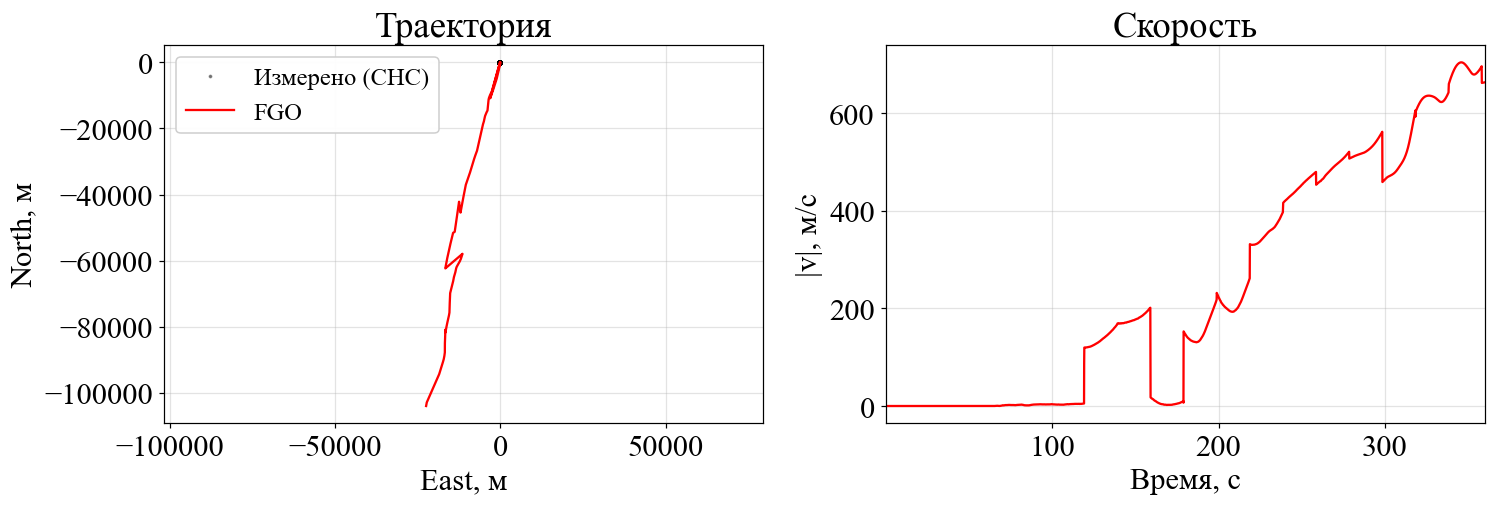

In [11]:
res = run_segment(str(SEG), method="fgo", show=True)